# Interactive Simplex Method in passagemath

**What this notebook shows:** passagemath can step through the simplex method pivot-by-pivot, rendering each dictionary as a LaTeX tableau. This is something cvxpy and JuMP don't do — it's built for understanding the algorithm, not just getting answers.

**Problem:** A small factory produces two goods, $x_1$ (widgets) and $x_2$ (gadgets).
- Profit: $5x_1 + 4x_2$
- Labor: $6x_1 + 4x_2 \leq 24$
- Materials: $x_1 + 2x_2 \leq 6$
- $x_1, x_2 \geq 0$

**Structure:** plot → dictionary → manual pivots → optimal → dual values.

In [ ]:
# Setup — run this first.
# Import order matters: MIP and matrix must load before interactive_simplex_method.
from sage.numerical.mip import MixedIntegerLinearProgram
import sage.matrix.constructor
import sage.rings.polynomial.laurent_polynomial_ring
from sage.numerical.interactive_simplex_method import InteractiveLPProblem

import re
from IPython.display import display, HTML, Latex
from sage.misc.latex import latex as _sage_latex

def _strip_tex(tex):
    """Strip commands incompatible with the Jupyter LaTeX renderer."""
    tex = re.sub(r'\\mspace\{[^}]*\}', '', tex)
    tex = re.sub(r'\\renewcommand\{[^}]*\}\{[^}]*\}', '', tex)
    tex = re.sub(r'%[^\n]*', '', tex)
    return tex.strip()

def show_dict(d):
    """Render an LPDictionary as a LaTeX tableau."""
    # Workaround: _sage_latex(d) returns a bare array block here, so wrap it in $$.
    # Remove once passagemath/passagemath fixes notebook LaTeX rendering for dictionaries.
    display(HTML('<p>$$' + _strip_tex(str(_sage_latex(d))) + '$$</p>'))

# Fix plot rendering: patch Graphics so plots display as images in Jupyter.
# Workaround for passagemath/passagemath#2351 (not yet merged).
from io import BytesIO
from matplotlib import rcParams
from matplotlib.backends.backend_agg import FigureCanvasAgg
from sage.plot.graphics import Graphics

def _graphics_repr_png(self):
    options = {}
    options.update(self.SHOW_OPTIONS)
    options.update(self._extra_kwds)
    dpi = options.pop('dpi')
    transparent = options.pop('transparent')
    fig_tight = options.pop('fig_tight')
    rc_backup = (rcParams['ps.useafm'], rcParams['pdf.use14corefonts'],
                 rcParams['text.usetex'])
    try:
        figure = self.matplotlib(**options)
        figure.set_canvas(FigureCanvasAgg(figure))
        figure.tight_layout()
        opts = {'dpi': dpi, 'transparent': transparent}
        if fig_tight:
            opts['bbox_inches'] = 'tight'
        extra = getattr(self, '_bbox_extra_artists', None)
        if extra:
            opts['bbox_extra_artists'] = extra
        buf = BytesIO()
        figure.savefig(buf, format='png', **opts)
        return buf.getvalue()
    finally:
        (rcParams['ps.useafm'], rcParams['pdf.use14corefonts'],
         rcParams['text.usetex']) = rc_backup

Graphics._repr_png_ = _graphics_repr_png

print("OK")

## Section 1: Define the problem and plot it

With only two decision variables we can draw the feasible region.

In [2]:
A = ([6, 4], [1, 2])
b = (24, 6)
c = (5, 4)

P = InteractiveLPProblem(A, b, c, ["x1", "x2"], variable_type=">=")
P

LP problem (use 'view(...)' or '%display typeset' for details)

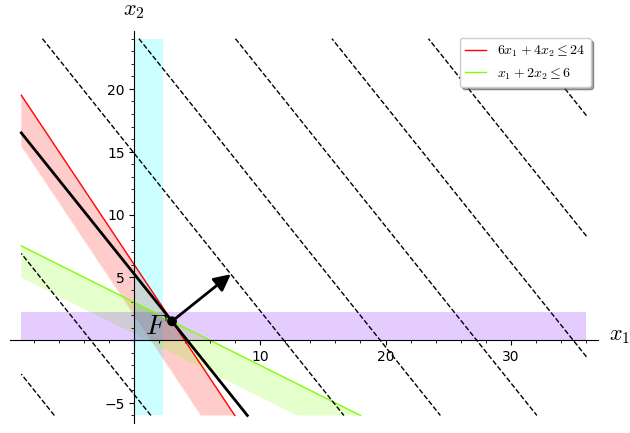

In [3]:
# Plot: feasible region (shaded), constraint lines, objective level curves
P.plot()

The feasible region is the shaded polygon. The optimal solution is at a vertex — the one that a level curve of the objective just barely touches. We can read it off visually, but let's confirm it algebraically with the simplex method.

## Section 2: Initial dictionary

The simplex method works on problems in **standard form**: all constraints as equalities by adding slack variables $x_3, x_4$. A **dictionary** expresses the basic variables (currently the slacks) in terms of the nonbasic variables (currently $x_1, x_2$).

In [ ]:
P = P.standard_form()
D = P.initial_dictionary()
show_dict(D)

In [ ]:
print("Feasible?", D.is_feasible())
print("Optimal?", D.is_optimal())
print("Basic variables:", D.basic_variables())
print("Basic solution (nonbasic = 0):", D.basic_solution())
print("Objective value:", D.objective_value())

We're at the origin: $x_1 = x_2 = 0$, profit = 0. Not optimal — the objective row shows both $x_1$ and $x_2$ have positive coefficients, so either can improve the objective.

## Section 3: Pivot 1

**Entering variable:** the nonbasic variable we bring into the basis — pick the one with the largest positive objective coefficient. Here that's $x_1$ (coefficient 5).

**Leaving variable:** determined by the minimum ratio test — which basic variable hits zero first as we increase $x_1$?

In [ ]:
print("Possible entering:", D.possible_entering())

In [ ]:
D.enter("x1")
print("Possible leaving:", D.possible_leaving())

In [ ]:
# x3 leaves (labor constraint binds first: 24/6 = 4, vs 6/1 = 6 for materials)
D.leave(3)
D.update()
show_dict(D)

In [ ]:
print("Feasible?", D.is_feasible())
print("Optimal?", D.is_optimal())
print("Objective value:", D.objective_value())

Profit improved. We moved from the origin to the vertex where the labor constraint is tight ($x_1 = 4$, $x_2 = 0$). One positive coefficient remains in the objective row, so we're not done.

## Section 4: Pivot 2

In [ ]:
print("Possible entering:", D.possible_entering())
D.enter("x2")
print("Possible leaving:", D.possible_leaving())

In [ ]:
D.leave(4)
D.update()
show_dict(D)

In [ ]:
print("Feasible?", D.is_feasible())
print("Optimal?", D.is_optimal())
print("Basic solution:", D.basic_solution())
print("Objective value:", D.objective_value())

No positive coefficients remain in the objective row — we're optimal. The solution is at the vertex where both constraints are tight.

## Section 5: Run it all at once

You can also ask passagemath to run all pivots and print every dictionary in sequence:

In [ ]:
# run_simplex_method returns an HtmlFragment with embedded equation* blocks
result = str(P.run_simplex_method())
for block in re.findall(r'\\begin\{equation\*\}.*?\\end\{equation\*\}', result, re.DOTALL):
    display(Latex(_strip_tex(block)))

## Section 6: Dual values (shadow prices)

The optimal dictionary encodes the dual solution directly — the coefficients of the slack variables $x_3, x_4$ in the objective row are the shadow prices of the constraints.

Shadow price of constraint $i$: how much does the optimal objective value increase if we relax $b_i$ by 1 unit?

In [ ]:
# Final dictionary from scratch (run_simplex_method modified D in place)
P2 = InteractiveLPProblem(A, b, c, ["x1", "x2"], variable_type=">=").standard_form()
D2 = P2.final_dictionary()
show_dict(D2)

In [ ]:
# The dual solution is the coefficient vector of the slacks in the objective row
dual = D2.objective_coefficients()
print("Objective coefficients:", dict(zip(D2.nonbasic_variables(), dual)))

The shadow price of the labor constraint tells us: one more unit of labor is worth this much profit. The shadow price of the materials constraint tells us how much one more unit of material is worth.

Notice that the signs on the slack variables in the objective row are the negatives of the shadow prices (the dictionary subtracts them). The dual values are the negatives of those coefficients.

## Section 7: Cross-check with MixedIntegerLinearProgram

The same shadow prices come from the GLPK backend — but the path to get them is buried.

In [ ]:
from sage.numerical.mip import MixedIntegerLinearProgram

lp = MixedIntegerLinearProgram(solver="GLPK", maximization=True)
x = lp.new_variable(nonnegative=True)

lp.set_objective(5*x[0] + 4*x[1])
lp.add_constraint(6*x[0] + 4*x[1] <= 24)  # labor
lp.add_constraint(x[0] + 2*x[1] <= 6)     # materials

lp.solve()
print("Optimal value:", lp.get_objective_value())
print("Solution:", lp.get_values(x))

In [ ]:
# Shadow prices via the GLPK backend
# Requires simplex_only mode — the default intopt solver does not populate dual values.
backend = lp.get_backend()
backend.solver_parameter("simplex_or_intopt", "simplex_only")
backend.solve()
for i in range(backend.nrows()):
    print(f"Constraint {i} shadow price: {backend.get_row_dual(i)}")

These should match the dual values from the dictionary. The fact that `get_row_dual` is not documented in `linear_programming.rst` is tracked in [passagemath#2347](https://github.com/passagemath/passagemath/issues/2347).

## Exercise

Change the problem to:
- Profit: $3x_1 + 5x_2$
- Labor: $x_1 + 2x_2 \leq 8$
- Materials: $3x_1 + 2x_2 \leq 12$
- $x_1, x_2 \geq 0$

1. Plot the new feasible region. Which vertex looks optimal?
2. Run the simplex method. How many pivots does it take?
3. What are the shadow prices? Which constraint is more valuable to relax?